In [2]:
import torch
print(torch.__version__)

2.10.0+cu126


In [8]:
names1 = [line.strip() for line in open("data/names1.txt",'r').read().splitlines()]
names1[:10]

['倪|子宁', '宋|云深', '尤|听澜', '唐|承安', '龙|长宁', '田|清玄', '柯|川', '郑|灵微', '任|瑶音', '汪|音']

In [10]:
len(names1)

12000

In [13]:
min_len = min(len(n) for n in names1)
max_len = max(len(n) for n in names1)

max_i=[i for i,n in enumerate(names1) if len(n)==max_len]

min_len-1,max_len-1,names1[max_i[0]] # 姓|名

(2, 4, '宇文|墨尘')

In [18]:
b={}
for n in names1:
    chs = ['<S>']+list(n)+['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0)+1
        #print(ch1,ch2)
# zip
# 倪|子宁
# |子宁

In [48]:
b

{('<S>', '倪'): 31,
 ('倪', '|'): 31,
 ('|', '子'): 453,
 ('子', '宁'): 44,
 ('宁', '<E>'): 827,
 ('<S>', '宋'): 108,
 ('宋', '|'): 108,
 ('|', '云'): 784,
 ('云', '深'): 48,
 ('深', '<E>'): 102,
 ('<S>', '尤'): 31,
 ('尤', '|'): 31,
 ('|', '听'): 246,
 ('听', '澜'): 53,
 ('澜', '<E>'): 147,
 ('<S>', '唐'): 107,
 ('唐', '|'): 107,
 ('|', '承'): 256,
 ('承', '安'): 48,
 ('安', '<E>'): 320,
 ('<S>', '龙'): 35,
 ('龙', '|'): 35,
 ('|', '长'): 406,
 ('长', '宁'): 44,
 ('<S>', '田'): 105,
 ('田', '|'): 105,
 ('|', '清'): 587,
 ('清', '玄'): 49,
 ('玄', '<E>'): 195,
 ('<S>', '柯'): 24,
 ('柯', '|'): 24,
 ('|', '川'): 49,
 ('川', '<E>'): 101,
 ('<S>', '郑'): 112,
 ('郑', '|'): 112,
 ('|', '灵'): 415,
 ('灵', '微'): 56,
 ('微', '<E>'): 572,
 ('<S>', '任'): 100,
 ('任', '|'): 100,
 ('|', '瑶'): 412,
 ('瑶', '音'): 46,
 ('音', '<E>'): 137,
 ('<S>', '汪'): 97,
 ('汪', '|'): 97,
 ('|', '音'): 41,
 ('<S>', '鲁'): 39,
 ('鲁', '|'): 39,
 ('|', '若'): 486,
 ('若', '云'): 53,
 ('云', '<E>'): 234,
 ('<S>', '萧'): 108,
 ('萧', '|'): 108,
 ('|', '怀'): 261,
 ('怀', '瑾

In [24]:
sorted(b.items(),key=lambda kv:-kv[1])

[(('宁', '<E>'), 827),
 (('|', '云'), 784),
 (('|', '青'), 753),
 (('|', '清'), 587),
 (('微', '<E>'), 572),
 (('|', '玄'), 487),
 (('|', '若'), 486),
 (('|', '子'), 453),
 (('远', '<E>'), 424),
 (('|', '灵'), 415),
 (('|', '瑶'), 412),
 (('衡', '<E>'), 410),
 (('|', '长'), 406),
 (('|', '墨'), 403),
 (('|', '玉'), 401),
 (('|', '归'), 400),
 (('|', '无'), 395),
 (('安', '<E>'), 320),
 (('|', '明'), 310),
 (('月', '<E>'), 304),
 (('明', '<E>'), 297),
 (('清', '<E>'), 295),
 (('渊', '<E>'), 292),
 (('|', '月'), 271),
 (('溪', '<E>'), 266),
 (('|', '澜'), 265),
 (('|', '怀'), 261),
 (('白', '<E>'), 260),
 (('|', '承'), 256),
 (('|', '听'), 246),
 (('|', '知'), 246),
 (('舟', '<E>'), 244),
 (('|', '雪'), 243),
 (('|', '修'), 239),
 (('|', '景'), 235),
 (('云', '<E>'), 234),
 (('|', '昭'), 230),
 (('|', '星'), 217),
 (('棠', '<E>'), 213),
 (('霄', '<E>'), 199),
 (('|', '晚'), 198),
 (('玄', '<E>'), 195),
 (('孙', '|'), 194),
 (('晴', '<E>'), 187),
 (('遥', '<E>'), 168),
 (('尘', '<E>'), 154),
 (('秋', '<E>'), 153),
 (('离', '<E>'), 152)

In [33]:
#set(''.join(names1))#去除重复元素
chars = sorted(list(set(''.join(names1))))
len(chars),chars[:10]

(346, ['|', '丁', '万', '上', '丛', '东', '严', '临', '乔', '书'])

In [58]:
stoi = {s:i for i,s in enumerate(chars)}
itos = {i:s for i,s in enumerate(chars)}
stoi['<S>'] = 346
stoi['<E>'] = 347
stoi['|'],stoi['风'],stoi['<S>'],itos[100]

(0, 332, 346, '康')

In [55]:
import torch
N = torch.zeros(len(stoi),len(stoi),dtype=torch.int32)
for n in names1:
    chs = ['<S>']+list(n)+['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1
N,N.shape

(tensor([[  0,   0,   0,  ...,   0,   0,   0],
         [100,   0,   0,  ...,   0,   0,   0],
         [ 28,   0,   0,  ...,   0,   0,   0],
         ...,
         [ 28,   0,   0,  ...,   0,   0,   0],
         [  0, 100,  28,  ...,  28,   0,   0],
         [  0,   0,   0,  ...,   0,   0,   0]], dtype=torch.int32),
 torch.Size([348, 348]))

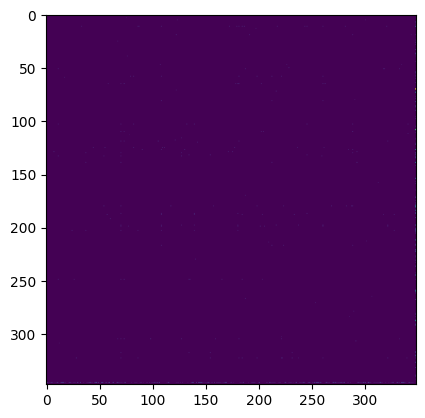

In [56]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)